# JADCO / Collection Équinoxe — moteur historique Same-Unit

Ce notebook utilise `src/same_unit.py`, après lecture du starter, de l’audit et de l’EDA. Il construit des transitions **consécutives** à unité constante, sans prévision, backtest, données externes ni choix définitif de cible.

La clé officielle est `UNIT_KEY = (sPropCode, sUnitCode)`, avec identifiants chargés comme chaînes. L’ordre utilise **sLeaseFrom**, date de début du bail, comme le starter : le changement de loyer est comparé entre débuts de baux, pas entre signatures ou échéances. L’année attribuée à une transition est celle du nouveau début.

Les paires restent uniquement en mémoire. Aucune paire, clé d’unité, adresse ou ligne brute n’est affichée ou exportée. Les statistiques des groupes de moins de cinq paires valides sont masquées ; leurs effectifs restent visibles. Les `NaN` affichés pour ces groupes ne signifient pas que les CSV contiennent des valeurs manquantes.

In [1]:
from pathlib import Path
import sys
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
sys.path.insert(0, str(Path('..').resolve()))
from src.same_unit import UNIT_KEY, build_same_unit_pairs
%matplotlib inline
plt.rcParams.update({'figure.figsize':(10,4), 'axes.spines.top':False, 'axes.spines.right':False})
pd.set_option('display.max_rows', 100)
protected = list(Path('../data/raw').glob('*.csv')) + [Path(x) for x in
    ['starter.ipynb','01_data_audit.ipynb','02_eda_mix_effect.ipynb']]
hashes = {p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
leases = pd.read_csv('../data/raw/equinoxe_lease_history.csv', dtype={c:'string' for c in UNIT_KEY})
pairs, trace = build_same_unit_pairs(leases)
TARGETS = ['contractual_growth','effective_growth',
           'contractual_annualized_growth','effective_annualized_growth']
LABELS = {'contractual_growth':'Contractuel brut', 'effective_growth':'Effectif brut',
          'contractual_annualized_growth':'Contractuel annualisé candidat',
          'effective_annualized_growth':'Effectif annualisé candidat'}

def summary(df, groups=None, columns=TARGETS):
    """Afficher uniquement des agrégats en pourcentage, jamais des paires."""
    rows=[]
    grouped = [((),df)] if not groups else df.groupby(groups, observed=True, dropna=False)
    for key, part in grouped:
        key = key if isinstance(key,tuple) else (key,)
        for col in columns:
            values = part[col].dropna()*100
            row = dict(zip(groups or [],key))
            row.update(mesure=LABELS.get(col,col), paires=len(values))
            for label,value in [('moyenne (%)',values.mean()),('médiane (%)',values.median()),
                                ('Q05 (%)',values.quantile(.05)),('Q25 (%)',values.quantile(.25)),
                                ('Q75 (%)',values.quantile(.75)),('Q95 (%)',values.quantile(.95))]:
                row[label] = value if len(values)>=5 else np.nan
            rows.append(row)
    return pd.DataFrame(rows).round(3)

def coverage(df, groups):
    rows=[]
    for key,part in df.groupby(groups, observed=True, dropna=False):
        key=key if isinstance(key,tuple) else (key,)
        row=dict(zip(groups,key))
        row.update(paires=len(part), unités=len(part[list(UNIT_KEY)].drop_duplicates()),
                   contractuelles_valides=int(part.valid_contractual.sum()),
                   effectives_valides=int(part.valid_effective.sum()))
        rows.append(row)
    return pd.DataFrame(rows)

def interpretation(text):display(Markdown('**Interprétation.** '+text))

## 1. Traçabilité et couverture

Le nombre théorique de transitions est `somme(N_baux_par_unité − 1)` pour les clés complètes. Les baux à clé manquante ne peuvent pas être attribués à une unité ; leur nombre est distinct, et ils rendent impossible une garantie de succession exhaustive. Une unité comportant une date de début invalide est mise à part en entier : aucune transition ne saute ce bail.

Dans une unité ordonnable, tout bail reste dans la séquence, même si son loyer est invalide. Les égalités de date sont ordonnées de façon déterministe selon l’ordre source, mais les transitions touchant ces dates ambiguës ne reçoivent pas de croissance valide. Les doublons ne sont pas retirés silencieusement.

Pour calculer une croissance valide, il faut la même clé, un ordre temporel strict sans date ambiguë et deux loyers finis strictement positifs. La validité est distincte pour les deux mesures. Les autres réserves de comparabilité restent des diagnostics, sans exclusion définitive.

In [2]:
trace_labels = {'total_leases':'Baux sources', 'identified_units':'Unités à clé complète',
    'missing_key_leases':'Baux à clé manquante', 'invalid_start_date_leases':'Baux à début invalide',
    'theoretical_transitions':'Transitions consécutives théoriques (clés complètes)',
    'quarantined_date_units':'Unités mises à part pour date invalide',
    'quarantined_date_leases':'Baux des unités mises à part',
    'unconstructed_date_transitions':'Transitions non construites : ordre indéterminable',
    'constructed_pairs':'Paires construites', 'paired_units':'Unités avec au moins une paire',
    'valid_temporal_pairs':'Paires temporellement valides',
    'valid_contractual_pairs':'Paires contractuelles valides', 'valid_effective_pairs':'Paires effectives valides',
    'valid_contractual_annualized_pairs':'Paires contractuelles annualisables',
    'valid_effective_annualized_pairs':'Paires effectives annualisables'}
display(pd.Series({trace_labels[k]:v for k,v in trace.items()}, name='Nombre').to_frame())
for groups in [['year'],['sPropCode','sBuilding'],['sState'],['sRenewal'],['year','sState'],['year','sRenewal']]:
    display(coverage(pairs,groups))
# Les premières observations ne sont pas des transitions ; elles restent dans les données sources.
print('Unités sans paire :', trace['identified_units']-trace['paired_units'])
assert pairs.flag_same_key.all()
assert len(pairs) + trace['unconstructed_date_transitions'] == trace['theoretical_transitions']
assert all(np.isfinite(pairs[c].dropna()).all() for c in TARGETS)

,Nombre
Baux sources,4302
Unités à clé complète,1061
Baux à clé manquante,0
Baux à début invalide,0
Transitions consécutives théoriques (clés complètes),3241
Unités mises à part pour date invalide,0
Baux des unités mises à part,0
Transitions non construites : ordre indéterminable,0
Paires construites,3241
Unités avec au moins une paire,892


,year,paires,unités,contractuelles_valides,effectives_valides
0,2017,3,3,3,3
1,2018,93,91,93,93
2,2019,166,164,166,166
3,2020,334,323,334,334
4,2021,361,357,361,361
5,2022,359,355,359,359
6,2023,424,420,424,424
7,2024,706,685,706,706
8,2025,795,789,795,795


,sPropCode,sBuilding,paires,unités,contractuelles_valides,effectives_valides
0,carlyle,Le Carlyle,343,190,343,343
1,dj1,Daniel-Johnson,333,58,333,333
2,dj2,Daniel-Johnson,215,76,215,215
3,levesque,Levesque,557,84,557,557
4,metcalfe,The Met,228,124,228,228
5,stelz1,Saint-Elzear,735,106,735,735
6,stelz2,Saint-Elzear,693,122,693,693
7,stelz3,Saint-Elzear,1,1,1,1
8,wsp1,Westpark,136,131,136,136


,sState,paires,unités,contractuelles_valides,effectives_valides
0,Ontario,228,124,228,228
1,Quebec,3013,768,3013,3013


,sRenewal,paires,unités,contractuelles_valides,effectives_valides
0,0,1276,651,1276,1276
1,1,1965,768,1965,1965


,year,sState,paires,unités,contractuelles_valides,effectives_valides
0,2017,Quebec,3,3,3,3
1,2018,Quebec,93,91,93,93
2,2019,Quebec,166,164,166,166
3,2020,Quebec,334,323,334,334
4,2021,Quebec,361,357,361,361
5,2022,Quebec,359,355,359,359
6,2023,Quebec,424,420,424,424
7,2024,Ontario,108,103,108,108
8,2024,Quebec,598,582,598,598
9,2025,Ontario,120,119,120,120


,year,sRenewal,paires,unités,contractuelles_valides,effectives_valides
0,2017,0,1,1,1,1
1,2017,1,2,2,2,2
2,2018,0,42,42,42,42
3,2018,1,51,50,51,51
4,2019,0,69,68,69,69
5,2019,1,97,97,97,97
6,2020,0,133,130,133,133
7,2020,1,201,200,201,201
8,2021,0,136,136,136,136
9,2021,1,225,225,225,225


Unités sans paire : 169


## 2. Diagnostics de comparabilité

Le tableau compte les paires concernées par chaque indicateur ; les indicateurs peuvent se chevaucher et ne sont donc pas additionnables. `flag_same_key` est une vérification positive, pas une anomalie.

- Une séquence `sTermSeq` ne progressant pas de 1 peut signaler une rupture d’historique ou une convention à clarifier.
- Une fin de bail antérieure au début est incohérente ; une ancienne fin postérieure au nouveau début signale un chevauchement à examiner (une égalité de dates n’est pas déclarée incohérente).
- Un changement de bâtiment ou de caractéristiques mérite examen avant une comparaison dite constante.
- La fenêtre du starter, `0.5 < days_between / 365.25 < 2.5`, est une **exclusion candidate de comparabilité**, conservée comme diagnostic et analyse de sensibilité.
- Les extrêmes sont signalés au-delà de `Q25 − 3 × IQR` ou `Q75 + 3 × IQR`, séparément pour chaque croissance brute. Ce seuil exploratoire n’est pas une preuve d’erreur et ne retire aucune paire.

In [3]:
diagnostics = pairs.filter(regex='^flag_').sum().rename('Paires concernées').to_frame()
display(diagnostics)
# Raisons explicites de pertes mathématiques, sans cumuler des flags qui se chevauchent.
loss = []
for target in ['contractual','effective']:
    temporal = pairs.valid_temporal
    valid = pairs['valid_'+target]
    loss.append({'mesure':target, 'construites':len(pairs),
                 'ordre invalide / ambigu':int((~temporal).sum()),
                 'loyer ou ratio invalide après ordre valide':int((temporal & ~valid).sum()),
                 'valides brutes':int(valid.sum()),
                 'annualisation non finie après validité brute':int((valid & ~pairs['valid_'+target+'_annualized']).sum())})
display(pd.DataFrame(loss))
# La sémantique de la durée contractuelle n'est pas confondue avec l'intervalle entre observations.
display(pairs['months_between'].describe(percentiles=[.05,.25,.5,.75,.95]).rename('Mois équivalents entre débuts').to_frame())
display(pairs.groupby('sRenewal').agg(paires=('year','size'),
    caractéristiques_modifiées=('flag_characteristics_changed','sum'),
    séquence_non_consécutive=('flag_term_sequence_not_next','sum'),
    intervalle_hors_fenêtre_starter=('flag_outside_starter_interval','sum')))
interpretation('Aucun flag de croissance extrême n’est utilisé comme filtre. Les réserves métiers restent distinctes de la possibilité mathématique de calculer un ratio.')

,Paires concernées
flag_same_key,3241
flag_nonpositive_interval,0
flag_ambiguous_date,0
flag_duplicate_source_row,0
flag_outside_starter_interval,62
flag_invalid_lease_end,0
flag_reversed_lease_dates,0
flag_overlap,0
flag_invalid_sign_date,0
flag_sign_after_start,0


,mesure,construites,ordre invalide / ambigu,loyer ou ratio invalide après ordre valide,valides brutes,annualisation non finie après validité brute
0,contractual,3241,0,0,3241,0
1,effective,3241,0,0,3241,0


,Mois équivalents entre débuts
count,3241.000000
mean,12.315361
std,1.792792
min,5.979466
5%,11.991786
25%,11.991786
50%,11.991786
75%,11.991786
95%,13.995893
max,25.264887


,paires,caractéristiques_modifiées,séquence_non_consécutive,intervalle_hors_fenêtre_starter
sRenewal,,,,
0,1276,0,0,16
1,1965,0,0,46


**Interprétation.** Aucun flag de croissance extrême n’est utilisé comme filtre. Les réserves métiers restent distinctes de la possibilité mathématique de calculer un ratio.

## 3. Croissance brute et annualisation candidate

Les deux croissances brutes sont calculées séparément : `new_sRent / old_sRent − 1` et `new_sRentEffective / old_sRentEffective − 1`. Les résultats sont stockés en fractions, affichés en pourcentage.

La durée explicite est `months_between = days_between / (365.25 / 12)`. L’annualisation candidate est `(new_rent / old_rent) ** (12 / months_between) − 1`, équivalente à la convention en années du starter. Elle exprime un rythme composé constant entre deux observations ; les loyers ne sont pas supposés avoir évolué régulièrement chaque mois. Elle ne doit pas être calculée en remplaçant l’intervalle réel par `sTermMonths`.

Toutes les paires mathématiquement valides sont conservées. Les quantiles 5–95 % décrivent la dispersion ; ils ne constituent pas une troncature des données.

,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,Contractuel brut,3241,4.611,4.341,0.000,2.581,6.467,9.871
1,Effectif brut,3241,3.106,2.972,-5.455,-0.081,6.007,12.071
2,Contractuel annualisé candidat,3241,4.584,4.269,0.000,2.474,6.379,9.969
3,Effectif annualisé candidat,3241,3.118,2.888,-5.316,-0.081,5.860,12.189


,year,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,2017,Contractuel brut,3,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,Effectif brut,3,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,Contractuel annualisé candidat,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,Effectif annualisé candidat,3,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,Contractuel brut,93,2.285,2.655,-2.319,1.015,3.774,5.496
5,2018,Effectif brut,93,2.105,2.172,-3.245,0.369,4.042,6.565
6,2018,Contractuel annualisé candidat,93,2.398,2.633,-2.321,1.012,3.798,6.250
7,2018,Effectif annualisé candidat,93,2.235,2.058,-3.247,0.370,4.148,6.641
8,2019,Contractuel brut,166,2.005,2.273,-2.156,0.800,3.257,5.852
9,2019,Effectif brut,166,1.598,1.741,-4.141,-1.172,4.175,7.357


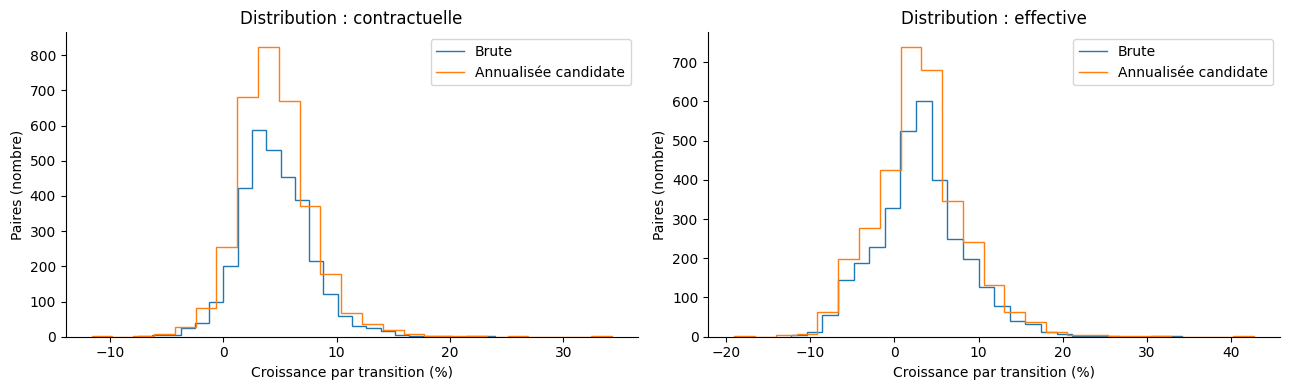

**Interprétation.** Les distributions comprennent toutes les valeurs valides, y compris les extrêmes. Annualiser amplifie les changements sur intervalles courts et réduit ceux sur intervalles longs ; cela peut modifier la moyenne et les quantiles davantage que la médiane.

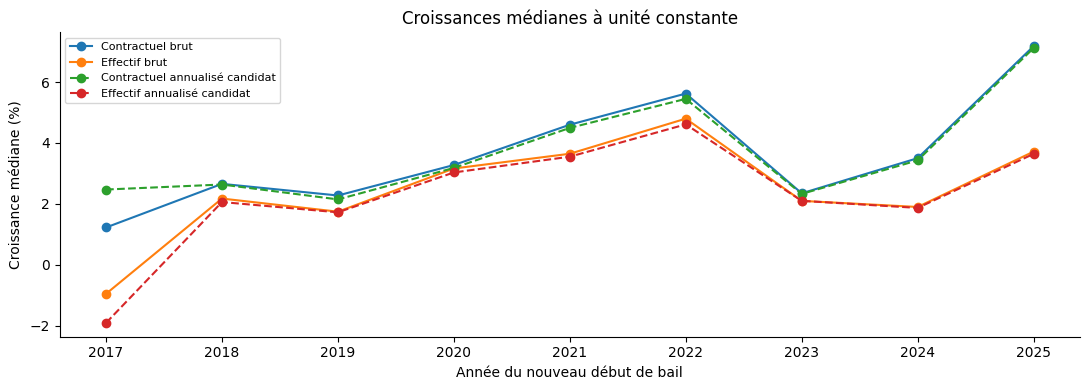

**Interprétation.** L’année regroupe les transitions dont le nouveau bail commence cette année. Une médiane brute combine des intervalles de durées différentes ; la médiane annualisée reste une candidate, sans choix définitif de target.

,year,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,2018,Contractuel brut,88,2.215,2.605,-2.322,0.948,3.778,5.402
1,2018,Effectif brut,88,2.069,2.070,-3.382,0.369,4.062,6.582
2,2018,Contractuel annualisé candidat,88,2.126,2.468,-2.323,0.893,3.751,5.405
3,2018,Effectif annualisé candidat,88,2.041,1.976,-3.384,0.366,4.048,6.587
4,2019,Contractuel brut,159,2.038,2.256,-2.048,0.800,3.255,5.919
5,2019,Effectif brut,159,1.639,1.709,-4.036,-1.215,4.244,7.371
6,2019,Contractuel annualisé candidat,159,2.000,2.142,-2.050,0.788,3.252,5.435
7,2019,Effectif annualisé candidat,159,1.593,1.629,-4.039,-1.154,4.222,7.295
8,2020,Contractuel brut,331,3.128,3.279,-0.832,1.862,4.458,6.515
9,2020,Effectif brut,331,2.852,3.158,-3.178,-0.108,5.356,9.467


Paires conservées pour cette sensibilité uniquement : 3179


In [4]:
display(summary(pairs))
display(summary(pairs,['year']))
fig,axes=plt.subplots(1,2,figsize=(13,4))
for target,ax in zip(['contractual','effective'],axes):
    for suffix,label in [('_growth','Brute'),('_annualized_growth','Annualisée candidate')]:
        vals=pairs[target+suffix].dropna().to_numpy()*100
        counts,edges=np.histogram(vals,bins=25)
        ax.stairs(counts,edges,label=label)
    ax.set(title=f'Distribution : {"contractuelle" if target=="contractual" else "effective"}',
           xlabel='Croissance par transition (%)',ylabel='Paires (nombre)')
    ax.legend()
plt.tight_layout();plt.show()
interpretation('Les distributions comprennent toutes les valeurs valides, y compris les extrêmes. Annualiser amplifie les changements sur intervalles courts et réduit ceux sur intervalles longs ; cela peut modifier la moyenne et les quantiles davantage que la médiane.')
annual_medians=pairs.groupby('year')[TARGETS].median()*100
fig,ax=plt.subplots(figsize=(11,4))
for col in TARGETS:
    ax.plot(annual_medians.index,annual_medians[col],marker='o',
            linestyle='--' if 'annualized' in col else '-',label=LABELS[col])
ax.set(title='Croissances médianes à unité constante',xlabel='Année du nouveau début de bail',ylabel='Croissance médiane (%)')
ax.legend(fontsize=8);plt.tight_layout();plt.show()
interpretation('L’année regroupe les transitions dont le nouveau bail commence cette année. Une médiane brute combine des intervalles de durées différentes ; la médiane annualisée reste une candidate, sans choix définitif de target.')
# Sensibilité explicite à la fenêtre du starter, pas changement du moteur.
inside=pairs.loc[~pairs.flag_outside_starter_interval]
display(summary(inside,['year']))
print('Paires conservées pour cette sensibilité uniquement :',len(inside))

## 4. Durées atypiques : 5.9, 17.9 et 23.9 mois

Les durées contractuelles atypiques sont étudiées du côté ancien et du côté nouveau. Les tableaux montrent leur association descriptive avec l’intervalle réel et les deux formes de croissance. Le contrat ancien est le repère le plus proche du temps jusqu’à la transition ; le contrat nouveau n’est pas la durée déjà écoulée.

Les deux côtés peuvent concerner la même paire : leurs effectifs ne s’additionnent pas. Aucune durée n’est corrigée ni arrondie à 6, 18 ou 24 mois.

In [5]:
term_tables=[]
for side in ['old','new']:
    term=pd.to_numeric(pairs[side+'_sTermMonths'],errors='coerce')
    for months in [5.9,12.0,17.9,23.9]:
        part=pairs.loc[term.eq(months)]
        row={'côté':side,'sTermMonths':months,'paires':len(part)}
        for label,values in [('intervalle médian (mois)',part.months_between),
                             ('intervalle − ancien terme médian (mois)',part.interval_minus_old_term_months)]:
            row[label]=values.median() if len(part)>=5 else np.nan
        term_tables.append(row)
    tmp=pairs.copy()
    tmp['durée contractuelle']=term
    display(summary(tmp,['durée contractuelle']))
display(pd.DataFrame(term_tables).round(3))
annualization_change=[]
for target in ['contractual','effective']:
    delta=(pairs[target+'_annualized_growth']-pairs[target+'_growth'])*100
    annualization_change.append({'mesure':target,'paires':int(delta.notna().sum()),
        'écart absolu moyen (points)':delta.abs().mean(),
        'écart absolu médian (points)':delta.abs().median(),
        'Q95 écart absolu (points)':delta.abs().quantile(.95)})
display(pd.DataFrame(annualization_change).round(3))
interpretation('L’annualisation est mathématiquement défendable sur les dates et ratios valides. Son interprétation économique exige encore de valider les périodes, l’étalement des concessions et la comparabilité ; elle n’est pas verrouillée.')

,durée contractuelle,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,5.9,Contractuel brut,72,4.391,4.131,0.130,2.908,6.076,8.746
1,5.9,Effectif brut,72,4.359,3.288,-1.152,2.050,6.486,12.592
2,5.9,Contractuel annualisé candidat,72,8.917,8.342,0.240,5.417,12.347,18.330
3,5.9,Effectif annualisé candidat,72,8.781,6.433,-2.298,4.157,12.721,25.512
4,12.0,Contractuel brut,3076,4.618,4.348,0.000,2.572,6.478,9.871
5,12.0,Effectif brut,3076,3.067,2.931,-5.499,-0.135,5.951,12.074
6,12.0,Contractuel annualisé candidat,3076,4.541,4.286,0.000,2.516,6.347,9.757
7,12.0,Effectif annualisé candidat,3076,3.019,2.865,-5.423,-0.133,5.806,11.961
8,17.9,Contractuel brut,60,4.125,3.725,0.000,2.509,6.287,8.320
9,17.9,Effectif brut,60,3.499,3.089,-3.365,-0.266,6.293,11.669


,durée contractuelle,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,5.9,Contractuel brut,57,2.021,1.961,0.253,0.962,3.182,4.071
1,5.9,Effectif brut,57,0.662,0.911,-7.196,-1.188,2.439,8.657
2,5.9,Contractuel annualisé candidat,57,1.924,1.930,0.200,0.962,2.839,3.810
3,5.9,Effectif annualisé candidat,57,0.708,0.911,-6.992,-1.189,2.327,8.567
4,12.0,Contractuel brut,3072,4.543,4.340,0.000,2.611,6.418,9.565
5,12.0,Effectif brut,3072,3.043,2.947,-5.425,-0.086,5.882,11.932
6,12.0,Contractuel annualisé candidat,3072,4.511,4.258,0.000,2.502,6.306,9.785
7,12.0,Effectif annualisé candidat,3072,3.051,2.866,-5.299,-0.085,5.743,11.998
8,17.9,Contractuel brut,59,6.959,6.840,0.000,3.775,9.350,14.746
9,17.9,Effectif brut,59,5.209,4.851,-5.793,1.718,8.138,16.674


,côté,sTermMonths,paires,intervalle médian (mois),intervalle − ancien terme médian (mois)
0,old,5.9,72,5.979,0.079
1,old,12.0,3076,11.992,-0.008
2,old,17.9,60,17.971,0.071
3,old,23.9,33,23.984,0.084
4,new,5.9,57,11.992,-0.008
5,new,12.0,3072,11.992,-0.008
6,new,17.9,59,11.992,-0.008
7,new,23.9,53,11.992,-0.008


,mesure,paires,écart absolu moyen (points),écart absolu médian (points),Q95 écart absolu (points)
0,contractual,3241,0.242,0.004,1.098
1,effective,3241,0.242,0.004,1.081


**Interprétation.** L’annualisation est mathématiquement défendable sur les dates et ratios valides. Son interprétation économique exige encore de valider les périodes, l’étalement des concessions et la comparabilité ; elle n’est pas verrouillée.

## 5. Segments : renouvellement, province, bâtiment et type d’unité

Les caractéristiques et `sRenewal` sont celles du nouveau bail ; leurs anciennes valeurs sont conservées en mémoire pour les diagnostics. Les statistiques pondèrent chaque transition également, pas chaque unité également. Une unité à plusieurs transitions pèse davantage. Les observations d’Ontario commencent plus tard ; une comparaison globale des provinces peut donc confondre province et période.

Les différences segmentées sont descriptives et ne démontrent aucune causalité. Un nouveau bâtiment sans ancien bail comparable n’entre pas immédiatement dans les paires.

,sRenewal,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,0,Contractuel brut,1276,4.828,4.520,-1.439,1.904,7.680,11.743
1,0,Effectif brut,1276,3.460,3.078,-5.148,-0.434,6.794,13.362
2,0,Contractuel annualisé candidat,1276,4.753,4.401,-1.476,1.887,7.505,11.569
3,0,Effectif annualisé candidat,1276,3.432,3.013,-5.128,-0.423,6.693,13.551
4,1,Contractuel brut,1965,4.470,4.251,1.091,2.857,6.080,8.030
5,1,Effectif brut,1965,2.876,2.917,-5.519,0.232,5.407,11.352
6,1,Contractuel annualisé candidat,1965,4.475,4.185,1.065,2.755,6.034,8.211
7,1,Effectif annualisé candidat,1965,2.914,2.857,-5.456,0.232,5.297,11.559


,sState,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,Ontario,Contractuel brut,228,5.838,5.767,1.371,3.510,7.872,10.714
1,Ontario,Effectif brut,228,2.649,2.689,-6.071,0.619,5.013,11.456
2,Ontario,Contractuel annualisé candidat,228,5.820,5.712,1.325,3.455,7.877,11.486
3,Ontario,Effectif annualisé candidat,228,2.663,2.600,-6.075,0.472,4.932,11.594
4,Quebec,Contractuel brut,3013,4.518,4.250,0.000,2.509,6.387,9.666
5,Quebec,Effectif brut,3013,3.141,2.994,-5.357,-0.126,6.059,12.084
6,Quebec,Contractuel annualisé candidat,3013,4.491,4.161,0.000,2.432,6.279,9.865
7,Quebec,Effectif annualisé candidat,3013,3.152,2.919,-5.231,-0.104,5.902,12.220


,sPropCode,sBuilding,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,carlyle,Le Carlyle,Contractuel brut,343,5.768,5.752,1.111,3.633,7.514,11.323
1,carlyle,Le Carlyle,Effectif brut,343,2.686,2.844,-6.364,0.040,5.236,11.535
2,carlyle,Le Carlyle,Contractuel annualisé candidat,343,5.656,5.559,1.108,3.580,7.420,11.070
3,carlyle,Le Carlyle,Effectif annualisé candidat,343,2.690,2.615,-6.355,0.040,5.153,12.153
4,dj1,Daniel-Johnson,Contractuel brut,333,4.612,4.339,0.510,3.041,6.301,9.252
5,dj1,Daniel-Johnson,Effectif brut,333,3.389,3.252,-5.138,0.201,6.061,11.989
6,dj1,Daniel-Johnson,Contractuel annualisé candidat,333,4.578,4.162,0.427,2.920,6.187,9.129
7,dj1,Daniel-Johnson,Effectif annualisé candidat,333,3.376,3.295,-5.062,0.201,5.906,11.699
8,dj2,Daniel-Johnson,Contractuel brut,215,4.620,4.036,-0.781,2.312,6.778,11.028
9,dj2,Daniel-Johnson,Effectif brut,215,2.769,2.563,-6.617,-1.926,6.847,13.446


,sBeds,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,0,Contractuel brut,103,5.447,5.344,0.609,3.259,7.556,11.897
1,0,Effectif brut,103,2.866,2.456,-5.691,0.110,6.248,12.294
2,0,Contractuel annualisé candidat,103,5.364,5.347,0.596,3.261,7.510,11.668
3,0,Effectif annualisé candidat,103,2.825,2.458,-5.695,0.110,6.253,11.729
4,1,Contractuel brut,878,4.923,4.651,0.388,2.973,6.607,10.135
5,1,Effectif brut,878,3.156,3.043,-5.762,0.000,5.859,12.098
6,1,Contractuel annualisé candidat,878,4.896,4.555,0.365,2.875,6.530,10.270
7,1,Effectif annualisé candidat,878,3.172,2.984,-5.470,0.000,5.785,12.196
8,2,Contractuel brut,2190,4.448,4.163,0.000,2.426,6.352,9.632
9,2,Effectif brut,2190,3.107,2.892,-5.333,-0.098,6.082,12.078


,sUnitSubtype,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,1 Bed,Contractuel brut,878,4.923,4.651,0.388,2.973,6.607,10.135
1,1 Bed,Effectif brut,878,3.156,3.043,-5.762,0.000,5.859,12.098
2,1 Bed,Contractuel annualisé candidat,878,4.896,4.555,0.365,2.875,6.530,10.270
3,1 Bed,Effectif annualisé candidat,878,3.172,2.984,-5.470,0.000,5.785,12.196
4,2 Bed,Contractuel brut,2190,4.448,4.163,0.000,2.426,6.352,9.632
5,2 Bed,Effectif brut,2190,3.107,2.892,-5.333,-0.098,6.082,12.078
6,2 Bed,Contractuel annualisé candidat,2190,4.422,4.092,0.000,2.332,6.248,9.771
7,2 Bed,Effectif annualisé candidat,2190,3.116,2.853,-5.232,-0.099,5.873,12.211
8,3 Bed,Contractuel brut,70,4.560,4.440,0.000,2.823,6.914,8.563
9,3 Bed,Effectif brut,70,2.785,3.079,-4.779,-0.258,5.265,10.010


,year,sRenewal,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,2017,0,Contractuel brut,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,0,Effectif brut,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,0,Contractuel annualisé candidat,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,0,Effectif annualisé candidat,1,NaN,NaN,NaN,NaN,NaN,NaN
4,2017,1,Contractuel brut,2,NaN,NaN,NaN,NaN,NaN,NaN
5,2017,1,Effectif brut,2,NaN,NaN,NaN,NaN,NaN,NaN
6,2017,1,Contractuel annualisé candidat,2,NaN,NaN,NaN,NaN,NaN,NaN
7,2017,1,Effectif annualisé candidat,2,NaN,NaN,NaN,NaN,NaN,NaN
8,2018,0,Contractuel brut,42,1.296,1.273,-3.077,-0.513,3.049,6.229
9,2018,0,Effectif brut,42,1.244,1.367,-4.325,-0.248,3.078,6.649


,year,sState,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,2017,Quebec,Contractuel brut,3,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,Quebec,Effectif brut,3,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,Quebec,Contractuel annualisé candidat,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,Quebec,Effectif annualisé candidat,3,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,Quebec,Contractuel brut,93,2.285,2.655,-2.319,1.015,3.774,5.496
5,2018,Quebec,Effectif brut,93,2.105,2.172,-3.245,0.369,4.042,6.565
6,2018,Quebec,Contractuel annualisé candidat,93,2.398,2.633,-2.321,1.012,3.798,6.250
7,2018,Quebec,Effectif annualisé candidat,93,2.235,2.058,-3.247,0.370,4.148,6.641
8,2019,Quebec,Contractuel brut,166,2.005,2.273,-2.156,0.800,3.257,5.852
9,2019,Quebec,Effectif brut,166,1.598,1.741,-4.141,-1.172,4.175,7.357


,year,sBuilding,mesure,paires,moyenne (%),médiane (%),Q05 (%),Q25 (%),Q75 (%),Q95 (%)
0,2017,Saint-Elzear,Contractuel brut,3,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,Saint-Elzear,Effectif brut,3,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,Saint-Elzear,Contractuel annualisé candidat,3,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,Saint-Elzear,Effectif annualisé candidat,3,NaN,NaN,NaN,NaN,NaN,NaN
4,2018,Levesque,Contractuel brut,1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
119,2025,The Met,Effectif annualisé candidat,120,3.252,3.388,-4.586,1.643,5.694,9.646
120,2025,Westpark,Contractuel brut,128,7.736,7.291,4.398,5.980,9.355,12.769
121,2025,Westpark,Effectif brut,128,3.832,3.790,-4.910,1.620,6.442,10.729
122,2025,Westpark,Contractuel annualisé candidat,128,7.768,7.210,4.402,5.841,9.418,12.222


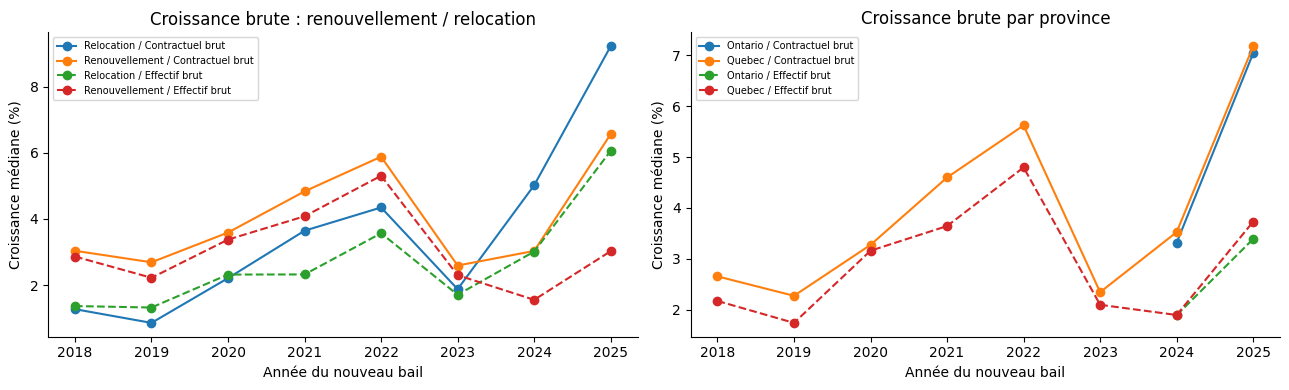

**Interprétation.** Comparer les provinces sur les années communes est plus défendable qu’une moyenne sur tout l’historique. Les écarts renouvellement/relocation peuvent aussi changer selon l’année et le bâtiment ; les deux mesures de loyer restent séparées.

In [6]:
for groups in [['sRenewal'],['sState'],['sPropCode','sBuilding'],['sBeds'],['sUnitSubtype'],
               ['year','sRenewal'],['year','sState'],['year','sBuilding']]:
    display(summary(pairs,groups))
fig,axes=plt.subplots(1,2,figsize=(13,4))
for col,style in [('contractual_growth','-'),('effective_growth','--')]:
    for group,ax in [('sRenewal',axes[0]),('sState',axes[1])]:
        grouped=pairs.groupby(['year',group])[col]
        med=(grouped.median().where(grouped.count().ge(5))*100).unstack()
        for category in med:
            name={0:'Relocation',1:'Renouvellement'}.get(category,str(category))
            ax.plot(med.index,med[category],marker='o',linestyle=style,label=f'{name} / {LABELS[col]}')
axes[0].set(title='Croissance brute : renouvellement / relocation',xlabel='Année du nouveau bail',ylabel='Croissance médiane (%)')
axes[1].set(title='Croissance brute par province',xlabel='Année du nouveau bail',ylabel='Croissance médiane (%)')
for ax in axes: ax.legend(fontsize=7)
plt.tight_layout();plt.show()
interpretation('Comparer les provinces sur les années communes est plus défendable qu’une moyenne sur tout l’historique. Les écarts renouvellement/relocation peuvent aussi changer selon l’année et le bâtiment ; les deux mesures de loyer restent séparées.')

## 6. Validation du problème de composition

La série EDA est reproduite uniquement pour comparer la variation de **médiane globale des niveaux** à la **médiane des variations individuelles** ; aucune EDA complète n’est refaite. Ces statistiques ont des populations différentes : tous les baux d’une année d’un côté, seulement les unités avec un bail précédent de l’autre. Les intervalles des transitions ne coïncident pas tous avec une année civile.

Cette comparaison met en évidence pourquoi la série brute ne suffit pas ; l’écart entre les courbes n’est pas une estimation causale exacte de l’effet de composition. La série candidate annualisée est ajoutée pour distinguer le rôle des intervalles.

,variation brute médiane contractuelle (%),same-unit contractuel brut (%),same-unit contractuel annualisé candidat (%),variation brute médiane effective (%),same-unit effectif brut (%),same-unit effectif annualisé candidat (%)
2017,NaN,1.222,2.468,NaN,-0.957,-1.911
2018,-11.295,2.655,2.633,-11.968,2.172,2.058
2019,7.453,2.273,2.144,6.958,1.741,1.720
2020,2.601,3.273,3.178,2.370,3.159,3.029
2021,4.225,4.598,4.493,2.882,3.644,3.547
2022,3.378,5.621,5.446,2.801,4.796,4.609
2023,10.850,2.344,2.325,10.376,2.096,2.098
2024,4.481,3.498,3.427,2.916,1.896,1.865
2025,4.063,7.177,7.113,1.014,3.714,3.639


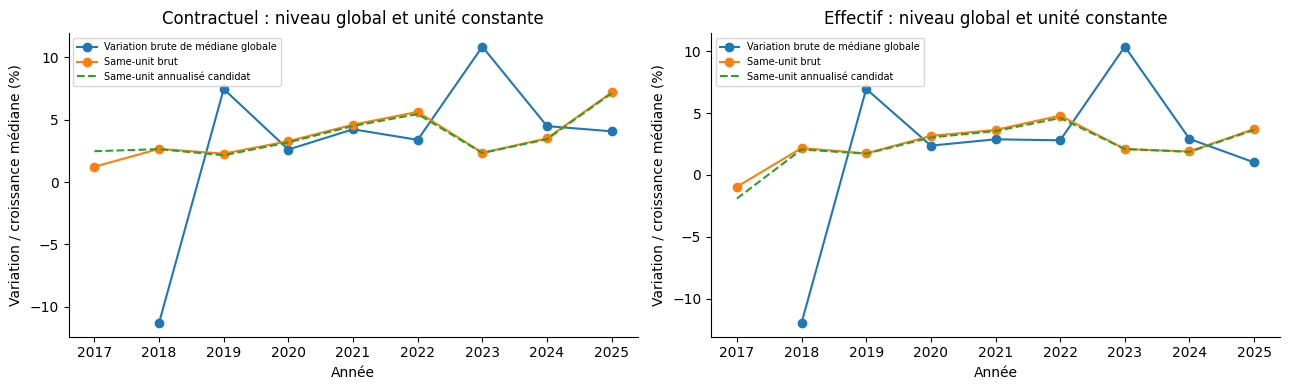

**Interprétation.** En 2023, la médiane contractuelle globale varie de 10.85 %, contre 2.34 % pour les transitions same-unit brutes et 2.32 % annualisées candidates. Les changements de composition documentés dans l’EDA et la sélection des unités comparables empêchent d’assimiler ces mesures.

In [7]:
lease_year=pd.to_datetime(leases.sLeaseFrom,errors='coerce',format='mixed').dt.year
raw_medians=leases.groupby(lease_year)[['sRent','sRentEffective']].median()
raw_change=raw_medians.pct_change()*100
comparison=pd.DataFrame({'variation brute médiane contractuelle (%)':raw_change.sRent,
    'same-unit contractuel brut (%)':annual_medians.contractual_growth,
    'same-unit contractuel annualisé candidat (%)':annual_medians.contractual_annualized_growth,
    'variation brute médiane effective (%)':raw_change.sRentEffective,
    'same-unit effectif brut (%)':annual_medians.effective_growth,
    'same-unit effectif annualisé candidat (%)':annual_medians.effective_annualized_growth})
display(comparison.round(3))
fig,axes=plt.subplots(1,2,figsize=(13,4))
for target,raw,label,ax in [('contractual','sRent','Contractuel',axes[0]),('effective','sRentEffective','Effectif',axes[1])]:
    ax.plot(raw_change.index,raw_change[raw],marker='o',label='Variation brute de médiane globale')
    ax.plot(annual_medians.index,annual_medians[target+'_growth'],marker='o',label='Same-unit brut')
    ax.plot(annual_medians.index,annual_medians[target+'_annualized_growth'],'--',label='Same-unit annualisé candidat')
    ax.set(title=f'{label} : niveau global et unité constante',xlabel='Année',ylabel='Variation / croissance médiane (%)')
    ax.legend(fontsize=7)
plt.tight_layout();plt.show()
interpretation(f"En 2023, la médiane contractuelle globale varie de {raw_change.loc[2023,'sRent']:.2f} %, contre {annual_medians.loc[2023,'contractual_growth']:.2f} % pour les transitions same-unit brutes et {annual_medians.loc[2023,'contractual_annualized_growth']:.2f} % annualisées candidates. Les changements de composition documentés dans l’EDA et la sélection des unités comparables empêchent d’assimiler ces mesures.")

## 7. Intégrité et vérifications finales

Les tests ciblés portent sur des baux synthétiques : clé officielle, ordre, succession, recomposition des deux ratios, annualisation, prix invalides, dates ambiguës, absence de saut de bail, conservation des extrêmes et absence de modification des entrées. Aucun test ne dépend d’enregistrements confidentiels. Les empreintes ci-dessous protègent les CSV et les notebooks précédents.

In [8]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==digest for p,digest in hashes.items())
print('CSV et notebooks précédents inchangés. Aucun export de paires, CSV ou dataset nettoyé.')

CSV et notebooks précédents inchangés. Aucun export de paires, CSV ou dataset nettoyé.


La cellule suivante régénère les conclusions à partir des agrégats calculés.

In [9]:
facts=[f"{trace['total_leases']} baux, {trace['identified_units']} unités et {trace['theoretical_transitions']} transitions théoriques ; {len(pairs)} paires construites sur {trace['paired_units']} unités. Les {trace['identified_units']-trace['paired_units']} unités sans paire ne permettent pas une croissance observée."]
quality=[f"{trace['valid_contractual_pairs']} paires contractuelles et {trace['valid_effective_pairs']} paires effectives valides. {trace['missing_key_leases']} baux à clé manquante, {trace['invalid_start_date_leases']} dates de début invalides, {int(pairs.flag_characteristics_changed.sum())} paires avec caractéristiques modifiées et {int(pairs.flag_term_sequence_not_next.sum())} séquences ne progressant pas de 1.",
         f"{int(pairs.flag_outside_starter_interval.sum())} paires hors fenêtre du starter conservées ; {int(pairs.flag_atypical_term.sum())} paires touchent une durée 5.9, 17.9 ou 23.9. Extrêmes IQR signalés : {int(pairs.flag_contractual_extreme_iqr.sum())} contractuels et {int(pairs.flag_effective_extreme_iqr.sum())} effectifs, tous conservés."]
contract=[f"En 2025, médiane brute {annual_medians.loc[2025,'contractual_growth']:.3f} %, annualisée candidate {annual_medians.loc[2025,'contractual_annualized_growth']:.3f} %. Sur l’ensemble des paires, médiane brute {pairs.contractual_growth.median()*100:.3f} % et moyenne brute {pairs.contractual_growth.mean()*100:.3f} %."]
effective=[f"En 2025, médiane brute {annual_medians.loc[2025,'effective_growth']:.3f} %, annualisée candidate {annual_medians.loc[2025,'effective_annualized_growth']:.3f} %. Sur l’ensemble des paires, médiane brute {pairs.effective_growth.median()*100:.3f} % et moyenne brute {pairs.effective_growth.mean()*100:.3f} %. Les mesures racontent des histoires différentes et ne sont pas substituées."]
for group in ['sRenewal','sState','sBuilding']:
    for category,part in pairs[pairs.year.eq(2025)].groupby(group):
        if min(part.contractual_growth.count(),part.effective_growth.count())>=5:
            facts.append(f"2025 — {group} = {category} : {len(part)} paires ; médianes brutes contractuelle {part.contractual_growth.median()*100:.3f} %, effective {part.effective_growth.median()*100:.3f} %.")
impact=[f"En 2023 : variation brute de médiane contractuelle {raw_change.loc[2023,'sRent']:.3f} %, same-unit brut {annual_medians.loc[2023,'contractual_growth']:.3f} %. Une statistique globale ne mesure pas la croissance d’une unité comparable."]
for target in ['contractual','effective']:
    difference=(pairs[target+'_annualized_growth']-pairs[target+'_growth']).abs()*100
    quality.append(f"Annualisation {target} : différence absolue médiane {difference.median():.3f} point et Q95 {difference.quantile(.95):.3f} point ; écart maximal entre médianes annuelles brute/annualisée {abs(annual_medians[target+'_annualized_growth']-annual_medians[target+'_growth']).max():.3f} point.")
sections={'FAITS CONFIRMÉS':facts,'QUALITÉ / COUVERTURE DES PAIRES':quality,
    'CROISSANCE CONTRACTUELLE OBSERVÉE':contract,'CROISSANCE EFFECTIVE OBSERVÉE':effective,
    'IMPACT DU MIX EFFECT':impact,
    'QUESTIONS ENCORE OUVERTES':[
        'L’annualisation est calculable et cohérente avec le starter, mais suppose un rythme composé entre observations ; elle reste candidate. Examiner les intervalles courts/longs et les termes atypiques avant de la retenir.',
        'Les comparaisons agrègent des transitions, pas des unités à poids égal. Les provinces ont des profondeurs historiques différentes et les bâtiments récemment observés offrent moins de paires.',
        'Examiner les extrêmes et les réserves de comparabilité individuellement dans un environnement confidentiel avant toute exclusion justifiée ; aucun filtre d’outlier automatique.',
        'Le résultat global n’est pas encore une target annuelle de portefeuille ; les pondérations, cohortes et fenêtres restent ouvertes.'],
    'DÉCISIONS POUR LA PHASE RENT ECONOMICS':[
        'Conserver les deux cibles, leurs anciennes/nouvelles concessions et les durées en mémoire ; déterminer les conventions de concessions, notamment PromoPay, sans conversion arbitraire.',
        'Étudier séparément renouvellement/relocation et Québec/Ontario, puis la variation par propriété/bâtiment ; aucune causalité ou règle réglementaire n’est inférée.',
        'Valider l’interprétation de sRentEffective et la cohérence des termes/échéances avant de décider de l’annualisation et du futur agrégat de portefeuille.']}
conclusion='## Constats du moteur Same-Unit\n\n'+'\n\n'.join('### '+title+'\n\n'+'\n'.join('- '+text for text in texts) for title,texts in sections.items())
display(Markdown(conclusion))

## Constats du moteur Same-Unit

### FAITS CONFIRMÉS

- 4302 baux, 1061 unités et 3241 transitions théoriques ; 3241 paires construites sur 892 unités. Les 169 unités sans paire ne permettent pas une croissance observée.
- 2025 — sRenewal = 0 : 312 paires ; médianes brutes contractuelle 9.225 %, effective 6.061 %.
- 2025 — sRenewal = 1 : 483 paires ; médianes brutes contractuelle 6.566 %, effective 3.027 %.
- 2025 — sState = Ontario : 120 paires ; médianes brutes contractuelle 7.041 %, effective 3.390 %.
- 2025 — sState = Quebec : 675 paires ; médianes brutes contractuelle 7.178 %, effective 3.730 %.
- 2025 — sBuilding = Daniel-Johnson : 130 paires ; médianes brutes contractuelle 7.160 %, effective 3.839 %.
- 2025 — sBuilding = Le Carlyle : 185 paires ; médianes brutes contractuelle 7.037 %, effective 3.590 %.
- 2025 — sBuilding = Levesque : 77 paires ; médianes brutes contractuelle 7.333 %, effective 3.312 %.
- 2025 — sBuilding = Saint-Elzear : 155 paires ; médianes brutes contractuelle 7.416 %, effective 3.918 %.
- 2025 — sBuilding = The Met : 120 paires ; médianes brutes contractuelle 7.041 %, effective 3.390 %.
- 2025 — sBuilding = Westpark : 128 paires ; médianes brutes contractuelle 7.291 %, effective 3.790 %.

### QUALITÉ / COUVERTURE DES PAIRES

- 3241 paires contractuelles et 3241 paires effectives valides. 0 baux à clé manquante, 0 dates de début invalides, 0 paires avec caractéristiques modifiées et 0 séquences ne progressant pas de 1.
- 62 paires hors fenêtre du starter conservées ; 322 paires touchent une durée 5.9, 17.9 ou 23.9. Extrêmes IQR signalés : 5 contractuels et 4 effectifs, tous conservés.
- Annualisation contractual : différence absolue médiane 0.004 point et Q95 1.098 point ; écart maximal entre médianes annuelles brute/annualisée 1.246 point.
- Annualisation effective : différence absolue médiane 0.004 point et Q95 1.081 point ; écart maximal entre médianes annuelles brute/annualisée 0.954 point.

### CROISSANCE CONTRACTUELLE OBSERVÉE

- En 2025, médiane brute 7.177 %, annualisée candidate 7.113 %. Sur l’ensemble des paires, médiane brute 4.341 % et moyenne brute 4.611 %.

### CROISSANCE EFFECTIVE OBSERVÉE

- En 2025, médiane brute 3.714 %, annualisée candidate 3.639 %. Sur l’ensemble des paires, médiane brute 2.972 % et moyenne brute 3.106 %. Les mesures racontent des histoires différentes et ne sont pas substituées.

### IMPACT DU MIX EFFECT

- En 2023 : variation brute de médiane contractuelle 10.850 %, same-unit brut 2.344 %. Une statistique globale ne mesure pas la croissance d’une unité comparable.

### QUESTIONS ENCORE OUVERTES

- L’annualisation est calculable et cohérente avec le starter, mais suppose un rythme composé entre observations ; elle reste candidate. Examiner les intervalles courts/longs et les termes atypiques avant de la retenir.
- Les comparaisons agrègent des transitions, pas des unités à poids égal. Les provinces ont des profondeurs historiques différentes et les bâtiments récemment observés offrent moins de paires.
- Examiner les extrêmes et les réserves de comparabilité individuellement dans un environnement confidentiel avant toute exclusion justifiée ; aucun filtre d’outlier automatique.
- Le résultat global n’est pas encore une target annuelle de portefeuille ; les pondérations, cohortes et fenêtres restent ouvertes.

### DÉCISIONS POUR LA PHASE RENT ECONOMICS

- Conserver les deux cibles, leurs anciennes/nouvelles concessions et les durées en mémoire ; déterminer les conventions de concessions, notamment PromoPay, sans conversion arbitraire.
- Étudier séparément renouvellement/relocation et Québec/Ontario, puis la variation par propriété/bâtiment ; aucune causalité ou règle réglementaire n’est inférée.
- Valider l’interprétation de sRentEffective et la cohérence des termes/échéances avant de décider de l’annualisation et du futur agrégat de portefeuille.

## Constats du moteur Same-Unit

### FAITS CONFIRMÉS

- 4302 baux, 1061 unités et 3241 transitions théoriques ; 3241 paires construites sur 892 unités. Les 169 unités sans paire ne permettent pas une croissance observée.
- 2025 — sRenewal = 0 : 312 paires ; médianes brutes contractuelle 9.225 %, effective 6.061 %.
- 2025 — sRenewal = 1 : 483 paires ; médianes brutes contractuelle 6.566 %, effective 3.027 %.
- 2025 — sState = Ontario : 120 paires ; médianes brutes contractuelle 7.041 %, effective 3.390 %.
- 2025 — sState = Quebec : 675 paires ; médianes brutes contractuelle 7.178 %, effective 3.730 %.
- 2025 — sBuilding = Daniel-Johnson : 130 paires ; médianes brutes contractuelle 7.160 %, effective 3.839 %.
- 2025 — sBuilding = Le Carlyle : 185 paires ; médianes brutes contractuelle 7.037 %, effective 3.590 %.
- 2025 — sBuilding = Levesque : 77 paires ; médianes brutes contractuelle 7.333 %, effective 3.312 %.
- 2025 — sBuilding = Saint-Elzear : 155 paires ; médianes brutes contractuelle 7.416 %, effective 3.918 %.
- 2025 — sBuilding = The Met : 120 paires ; médianes brutes contractuelle 7.041 %, effective 3.390 %.
- 2025 — sBuilding = Westpark : 128 paires ; médianes brutes contractuelle 7.291 %, effective 3.790 %.

### QUALITÉ / COUVERTURE DES PAIRES

- 3241 paires contractuelles et 3241 paires effectives valides. 0 baux à clé manquante, 0 dates de début invalides, 0 paires avec caractéristiques modifiées et 0 séquences ne progressant pas de 1.
- 62 paires hors fenêtre du starter conservées ; 322 paires touchent une durée 5.9, 17.9 ou 23.9. Extrêmes IQR signalés : 5 contractuels et 4 effectifs, tous conservés.
- Annualisation contractual : différence absolue médiane 0.004 point et Q95 1.098 point ; écart maximal entre médianes annuelles brute/annualisée 1.246 point.
- Annualisation effective : différence absolue médiane 0.004 point et Q95 1.081 point ; écart maximal entre médianes annuelles brute/annualisée 0.954 point.

### CROISSANCE CONTRACTUELLE OBSERVÉE

- En 2025, médiane brute 7.177 %, annualisée candidate 7.113 %. Sur l’ensemble des paires, médiane brute 4.341 % et moyenne brute 4.611 %.

### CROISSANCE EFFECTIVE OBSERVÉE

- En 2025, médiane brute 3.714 %, annualisée candidate 3.639 %. Sur l’ensemble des paires, médiane brute 2.972 % et moyenne brute 3.106 %. Les mesures racontent des histoires différentes et ne sont pas substituées.

### IMPACT DU MIX EFFECT

- En 2023 : variation brute de médiane contractuelle 10.850 %, same-unit brut 2.344 %. Une statistique globale ne mesure pas la croissance d’une unité comparable.

### QUESTIONS ENCORE OUVERTES

- L’annualisation est calculable et cohérente avec le starter, mais suppose un rythme composé entre observations ; elle reste candidate. Examiner les intervalles courts/longs et les termes atypiques avant de la retenir.
- Les comparaisons agrègent des transitions, pas des unités à poids égal. Les provinces ont des profondeurs historiques différentes et les bâtiments récemment observés offrent moins de paires.
- Examiner les extrêmes et les réserves de comparabilité individuellement dans un environnement confidentiel avant toute exclusion justifiée ; aucun filtre d’outlier automatique.
- Le résultat global n’est pas encore une target annuelle de portefeuille ; les pondérations, cohortes et fenêtres restent ouvertes.

### DÉCISIONS POUR LA PHASE RENT ECONOMICS

- Conserver les deux cibles, leurs anciennes/nouvelles concessions et les durées en mémoire ; déterminer les conventions de concessions, notamment PromoPay, sans conversion arbitraire.
- Étudier séparément renouvellement/relocation et Québec/Ontario, puis la variation par propriété/bâtiment ; aucune causalité ou règle réglementaire n’est inférée.
- Valider l’interprétation de sRentEffective et la cohérence des termes/échéances avant de décider de l’annualisation et du futur agrégat de portefeuille.